# EDA – CREMA-D Dataset

Exploračná analýza CREMA-D (Crowd-sourced Emotional Multimodal Actors Dataset) datasetu.

- Počet vzoriek a distribúcia labels
- Vizualizácia MFCC+delta+delta2 a spektrogramov
- Počet hercov a nahrávok na herca

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Pridaj projekt root
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import Config

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Načítaj metadata

In [2]:
metadata_path = Config.CREMAD_PROCESSED_PATH / "metadata.csv"
df = pd.read_csv(metadata_path)

print(f"Celkom vzoriek: {len(df)}")
print(f"\nStĺpce: {df.columns.tolist()}")
print(f"\nPrvých 5 riadkov:")
print(df.head())
print(f"\nInfo o datasete:")
print(df.info())

Celkom vzoriek: 7441

Stĺpce: ['filename', 'actor_id', 'sentence', 'emotion', 'intensity', 'label', 'feat_path', 'spec_path']

Prvých 5 riadkov:
              filename  actor_id sentence emotion intensity  label  \
0  1001_DFA_ANG_XX.wav      1001      DFA     ANG        XX      1   
1  1001_DFA_DIS_XX.wav      1001      DFA     DIS        XX      1   
2  1001_DFA_FEA_XX.wav      1001      DFA     FEA        XX      1   
3  1001_DFA_HAP_XX.wav      1001      DFA     HAP        XX      0   
4  1001_DFA_NEU_XX.wav      1001      DFA     NEU        XX      0   

                                           feat_path  \
0  data\processed\cremad\features\1001_DFA_ANG_XX...   
1  data\processed\cremad\features\1001_DFA_DIS_XX...   
2  data\processed\cremad\features\1001_DFA_FEA_XX...   
3  data\processed\cremad\features\1001_DFA_HAP_XX...   
4  data\processed\cremad\features\1001_DFA_NEU_XX...   

                                           spec_path  
0  data\processed\cremad\spectrograms\1001

## 2. Distribúcia labels

Distribúcia labels:
label
0    2358
1    5083
Name: count, dtype: int64

Procenta:
label
0    31.689289
1    68.310711
Name: proportion, dtype: float64


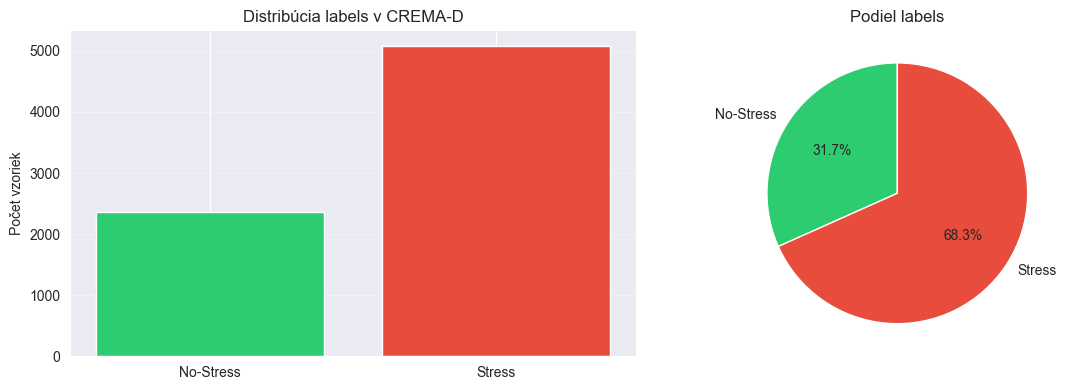

In [3]:
# Počet vzoriek pre každý label
label_counts = df['label'].value_counts().sort_index()
print("Distribúcia labels:")
print(label_counts)
print(f"\nProcenta:")
print(df['label'].value_counts(normalize=True).sort_index() * 100)

# Vizualizácia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
label_names = {0: 'No-Stress', 1: 'Stress'}
colors = ['#2ecc71', '#e74c3c']
axes[0].bar([label_names[i] for i in label_counts.index], label_counts.values, color=colors)
axes[0].set_ylabel('Počet vzoriek')
axes[0].set_title('Distribúcia labels v CREMA-D')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(label_counts.values, labels=[label_names[i] for i in label_counts.index],
             autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Podiel labels')

plt.tight_layout()
plt.show()

## 3. Emócie a distribúcia hercov

Distribúcia emócií v CREMA-D:
emotion
ANG    1271
DIS    1271
FEA    1271
HAP    1271
SAD    1270
NEU    1087
Name: count, dtype: int64

Celkový počet hercov: 91
Vzoriek na herca (priemer): 81.8


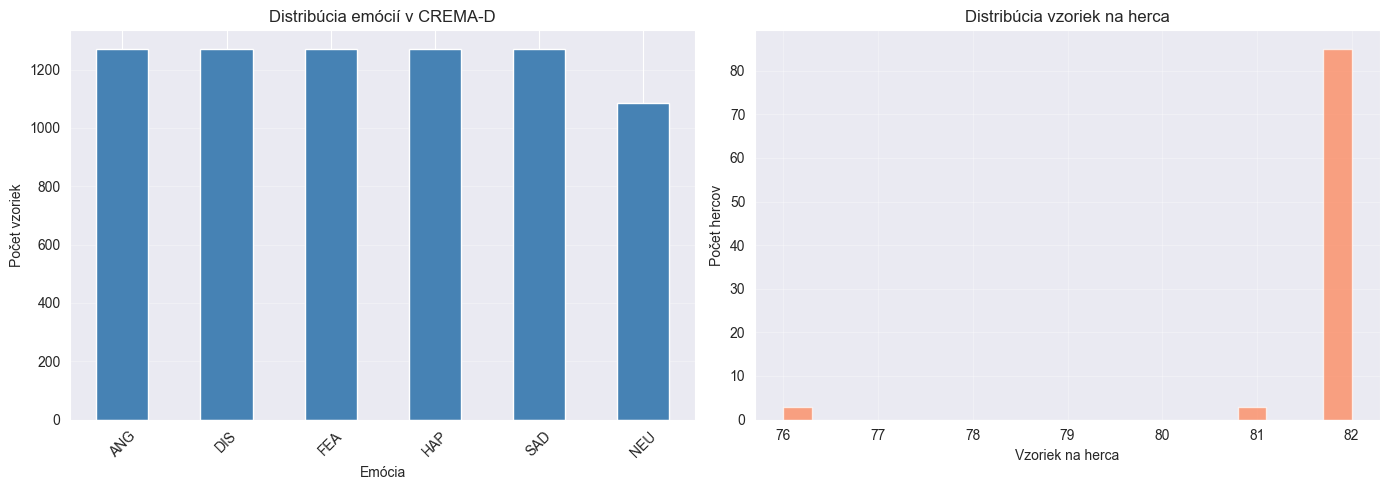

In [4]:
# Počet vzoriek pre každú emóciu
emotion_counts = df['emotion'].value_counts()
print("Distribúcia emócií v CREMA-D:")
print(emotion_counts)

# Informácie o hercoch
n_actors = df['actor_id'].nunique()
print(f"\nCelkový počet hercov: {n_actors}")
print(f"Vzoriek na herca (priemer): {len(df) / n_actors:.1f}")

# Vizualizácia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Emócie
emotion_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_ylabel('Počet vzoriek')
axes[0].set_xlabel('Emócia')
axes[0].set_title('Distribúcia emócií v CREMA-D')
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Herci
actor_counts = df['actor_id'].value_counts().sort_index()
axes[1].hist(actor_counts.values, bins=20, color='coral', alpha=0.7)
axes[1].set_ylabel('Počet hercov')
axes[1].set_xlabel('Vzoriek na herca')
axes[1].set_title('Distribúcia vzoriek na herca')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Vizualizácia MFCC+delta+delta2 a spektrogramu

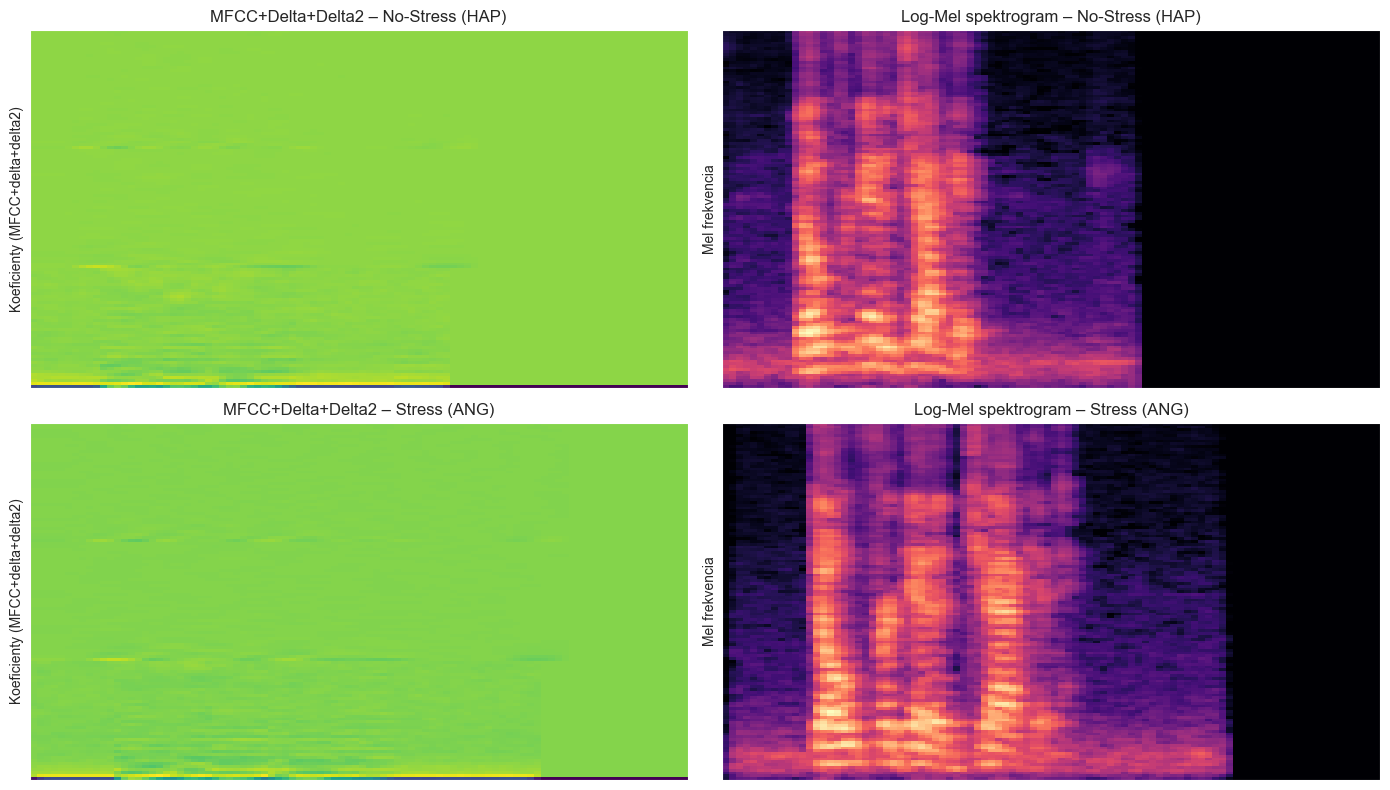

No-Stress príklad: HAP – Actor 1001
Stress príklad: ANG – Actor 1001


In [5]:
import librosa.display

# Vyber prvú vzorku z každého labelu
no_stress_sample = df[df['label'] == 0].iloc[0]
stress_sample = df[df['label'] == 1].iloc[0]

# Načítaj a zobrazi
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (sample, row_idx) in enumerate([(no_stress_sample, 0), (stress_sample, 1)]):
    # MFCC + delta + delta2 (120 koeficientov)
    mfcc_path = Config.ROOT_DIR / sample['feat_path']
    mfcc = np.load(mfcc_path)
    
    librosa.display.specshow(mfcc, ax=axes[idx, 0], cmap='viridis')
    axes[idx, 0].set_title(f"MFCC+Delta+Delta2 – {'No-Stress' if sample['label'] == 0 else 'Stress'} ({sample['emotion']})")
    axes[idx, 0].set_ylabel('Koeficienty (MFCC+delta+delta2)')
    
    # Log-Mel spektrogram
    spec_path = Config.ROOT_DIR / sample['spec_path']
    spec = np.load(spec_path)
    
    librosa.display.specshow(spec, ax=axes[idx, 1], cmap='magma', sr=Config.SAMPLE_RATE)
    axes[idx, 1].set_title(f"Log-Mel spektrogram – {'No-Stress' if sample['label'] == 0 else 'Stress'} ({sample['emotion']})")
    axes[idx, 1].set_ylabel('Mel frekvencia')

plt.tight_layout()
plt.show()

print(f"No-Stress príklad: {no_stress_sample['emotion']} – Actor {no_stress_sample['actor_id']}")
print(f"Stress príklad: {stress_sample['emotion']} – Actor {stress_sample['actor_id']}")

## 5. Štatistika veľkostí features

MFCC+Delta+Delta2 time-frames (počet vzoriek): 7441
  Priemer: 94.0
  Min: 94
  Max: 94

Log-Mel spektrogram time-frames:
  Priemer: 94.0
  Min: 94
  Max: 94


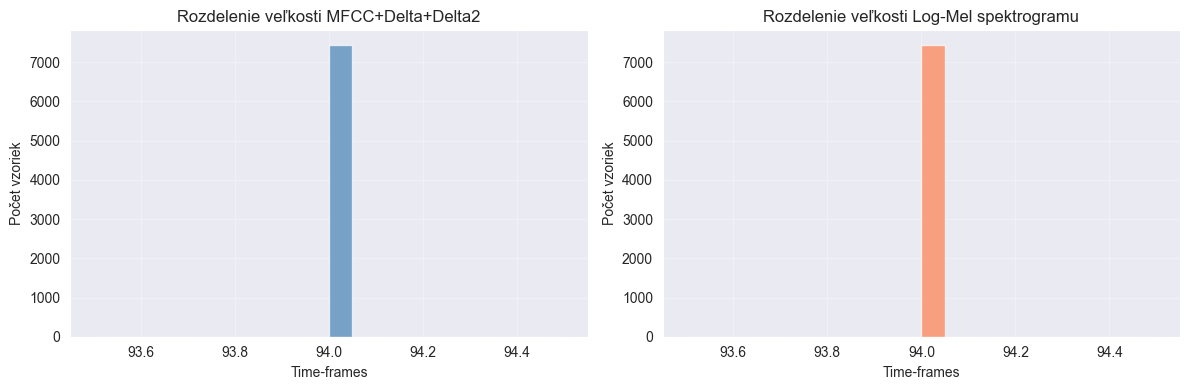

In [6]:
# Analýza rozmerov MFCC+delta+delta2 a spektrogramov
feat_shapes = []
spec_shapes = []

for idx, row in df.iterrows():
    feat = np.load(Config.ROOT_DIR / row['feat_path'])
    spec = np.load(Config.ROOT_DIR / row['spec_path'])
    feat_shapes.append(feat.shape[1])  # Počet time-frameov
    spec_shapes.append(spec.shape[1])

print(f"MFCC+Delta+Delta2 time-frames (počet vzoriek): {len(feat_shapes)}")
print(f"  Priemer: {np.mean(feat_shapes):.1f}")
print(f"  Min: {np.min(feat_shapes)}")
print(f"  Max: {np.max(feat_shapes)}")

print(f"\nLog-Mel spektrogram time-frames:")
print(f"  Priemer: {np.mean(spec_shapes):.1f}")
print(f"  Min: {np.min(spec_shapes)}")
print(f"  Max: {np.max(spec_shapes)}")

# Vizualizácia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(feat_shapes, bins=20, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Time-frames')
axes[0].set_ylabel('Počet vzoriek')
axes[0].set_title('Rozdelenie veľkosti MFCC+Delta+Delta2')
axes[0].grid(alpha=0.3)

axes[1].hist(spec_shapes, bins=20, color='coral', alpha=0.7)
axes[1].set_xlabel('Time-frames')
axes[1].set_ylabel('Počet vzoriek')
axes[1].set_title('Rozdelenie veľkosti Log-Mel spektrogramu')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()